In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

trades = pd.read_csv(r"C:\abhinav\prime trade ai (task)\historical_data.csv")
sentiment = pd.read_csv(r"C:\abhinav\prime trade ai (task)\fear_greed_index.csv")

In [7]:
print(trades.shape)
print(sentiment.shape)

(211224, 16)
(2644, 4)


In [8]:
trades.info()
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [9]:
trades.isnull().sum()
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
trades.duplicated().sum()
sentiment.duplicated().sum()

np.int64(0)

## Convert Dates

In [13]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date']


In [15]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

trades['Date'] = trades['Timestamp'].dt.date

In [16]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['Date'] = trades['Timestamp IST'].dt.date

In [17]:
print(sentiment.columns.tolist())

['timestamp', 'value', 'classification', 'date']


In [19]:
# Convert Trades Timestamp
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['Date'] = trades['Timestamp'].dt.date

# Convert Sentiment Date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Check
print(trades[['Date']].head())
print(sentiment[['date']].head())

         Date
0  2024-10-27
1  2024-10-27
2  2024-10-27
3  2024-10-27
4  2024-10-27
         date
0  2018-02-01
1  2018-02-02
2  2018-02-03
3  2018-02-04
4  2018-02-05


In [21]:
print(trades.columns.tolist())
print(sentiment.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date']
['timestamp', 'value', 'classification', 'date']


## Merge

In [26]:
df = pd.merge(
    trades,
    sentiment,
    on='Date',
    how='left'
)

print(df.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

## Feature Engineering

In [28]:
daily_pnl = (
    df.groupby(['Date', 'Account'])['Closed PnL']
      .sum()
      .reset_index()
)

print(daily_pnl.head())

         Date                                     Account   Closed PnL
0  2023-03-28  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000
1  2023-11-14  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000
2  2023-11-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   155.503357
3  2024-03-09  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891 -5564.016140
4  2024-03-09  0x430f09841d65beb3f27765503d0f850b8bce7713     0.000000


## WIN RATE

In [30]:
# Create Win column
df['Win'] = df['Closed PnL'] > 0

# Calculate win rate
win_rate = (
    df.groupby('Account')['Win']
      .mean()
      .reset_index()
)

# Convert to percentage
win_rate['Win Rate (%)'] = win_rate['Win'] * 100

print(win_rate.head())

                                      Account       Win  Win Rate (%)
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612     35.961236
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720     44.271978
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917     30.191651
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585     43.858463
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914     51.991355


## Average Trade Size

In [32]:
trade_size = (
    df.groupby('Account')['Size USD']
      .mean()
      .reset_index()
)

print(trade_size.head())

                                      Account      Size USD
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327
2  0x271b280974205ca63b716753467d5a371de622ab   8893.000898
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782


## Daily Trade Count

In [34]:
trade_count = (
    df.groupby(['Date', 'Account'])
      .size()
      .reset_index(name='Trades')
)

print(trade_count.head())

         Date                                     Account  Trades
0  2023-03-28  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891       3
1  2023-11-14  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891       2
2  2023-11-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1043
3  2024-03-09  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891      27
4  2024-03-09  0x430f09841d65beb3f27765503d0f850b8bce7713      88


## Average Leverage

In [35]:
trade_size = (
    df.groupby('Account')['Size USD']
      .mean()
      .reset_index()
)

print(trade_size.head())

                                      Account      Size USD
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327
2  0x271b280974205ca63b716753467d5a371de622ab   8893.000898
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782


## Long Short Ratio

In [36]:
long_short = (
    df.groupby(['classification', 'Side'])
      .size()
      .unstack(fill_value=0)
)

print(long_short)

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


# PART-B ANALYSIS


# Fear vs Greed Performance

In [38]:
df.groupby('classification')['Closed PnL'].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Greed,6962.0,25.418772,306.166937,-21524.40000,0.0,0.0,16.186514,2500.95750
Fear,133871.0,50.047622,909.121796,-35681.74723,0.0,0.0,6.042830,135329.09010
Greed,36289.0,87.894859,1148.343968,-117990.10410,0.0,0.0,9.239366,44223.45187
Neutral,7141.0,22.229713,633.704815,-18360.67007,0.0,0.0,1.950048,18282.19011


### PLOT

<module 'matplotlib.pyplot' from 'C:\\Users\\Mygold\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\matplotlib\\pyplot.py'>

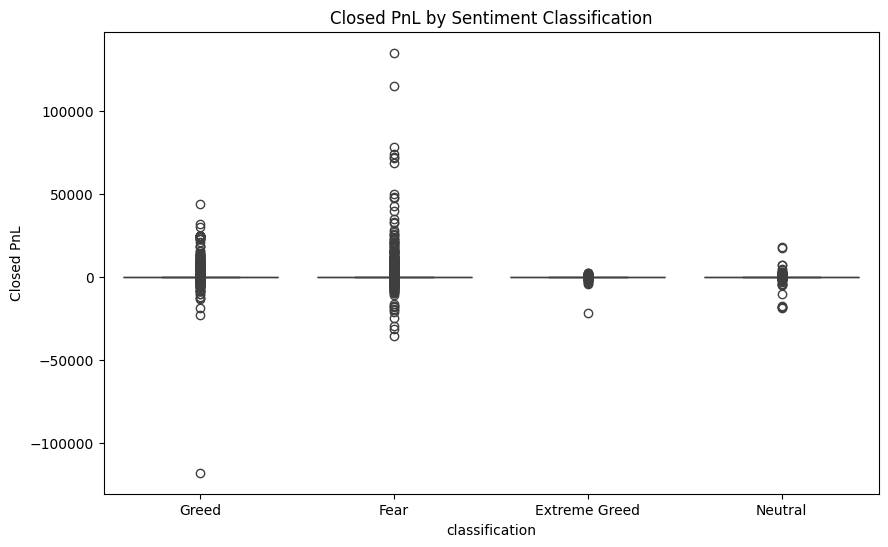

In [40]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='classification',
    y='Closed PnL'
)

plt.title("Closed PnL by Sentiment Classification")
plt

## 2.Leverage Distribution

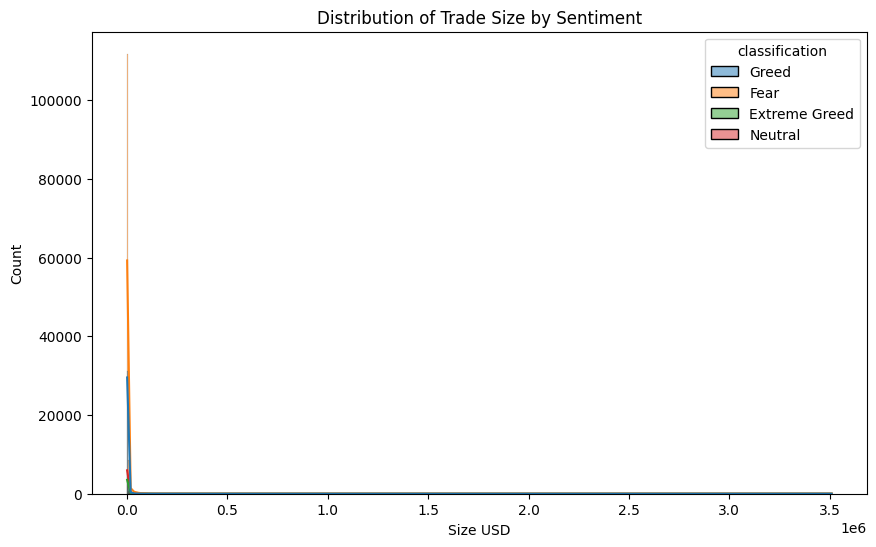

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Size USD',
    hue='classification',
    kde=True
)

plt.title("Distribution of Trade Size by Sentiment")
plt.show()

## Trade Frequency

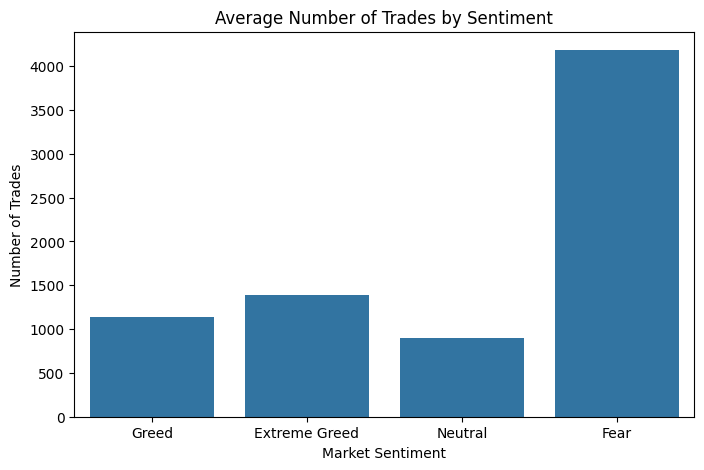

In [44]:


# Merge trade_count with sentiment on Date
trade_sentiment = trade_count.merge(sentiment, on='Date', how='left')

plt.figure(figsize=(8, 5))

sns.barplot(
    data=trade_sentiment,
    x='classification',
    y='Trades',
    errorbar=None
)

plt.title("Average Number of Trades by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

## Position Size

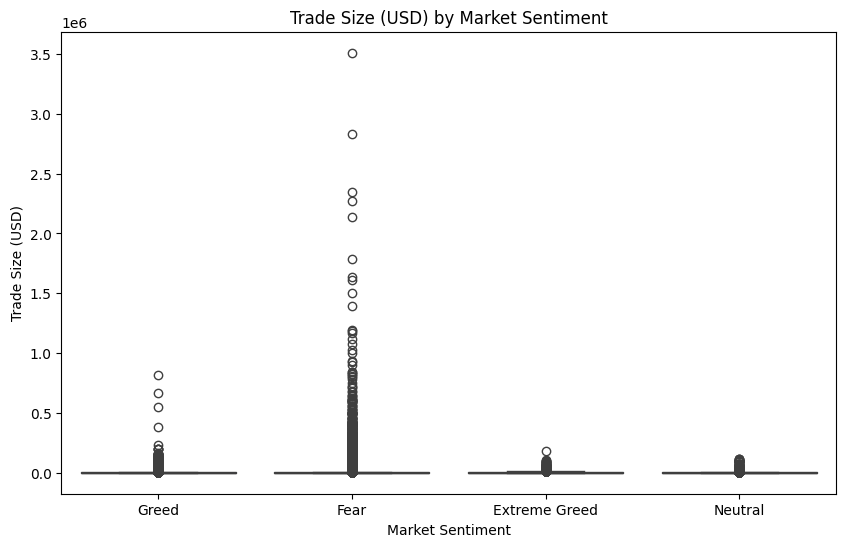

In [45]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='classification',
    y='Size USD'
)

plt.title("Trade Size (USD) by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (USD)")
plt.show()

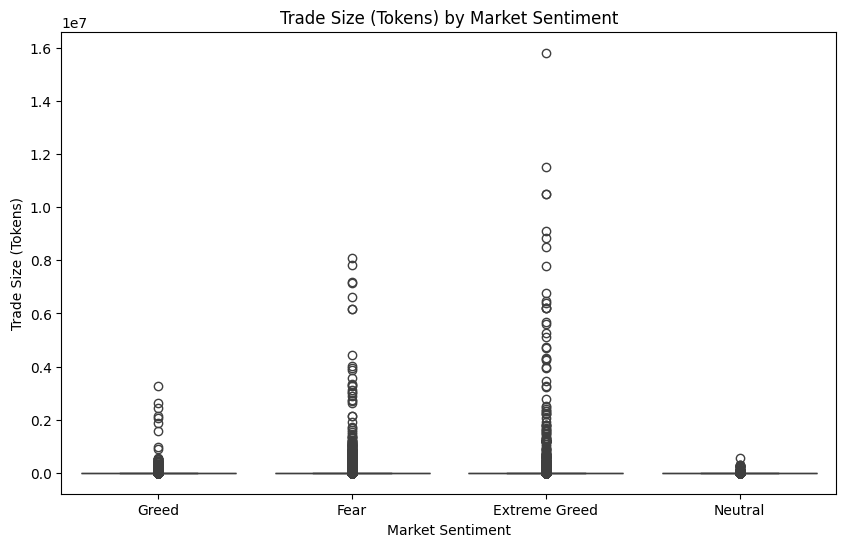

In [46]:


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='classification',
    y='Size Tokens'
)

plt.title("Trade Size (Tokens) by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (Tokens)")
plt.show()

## Trade Frequency

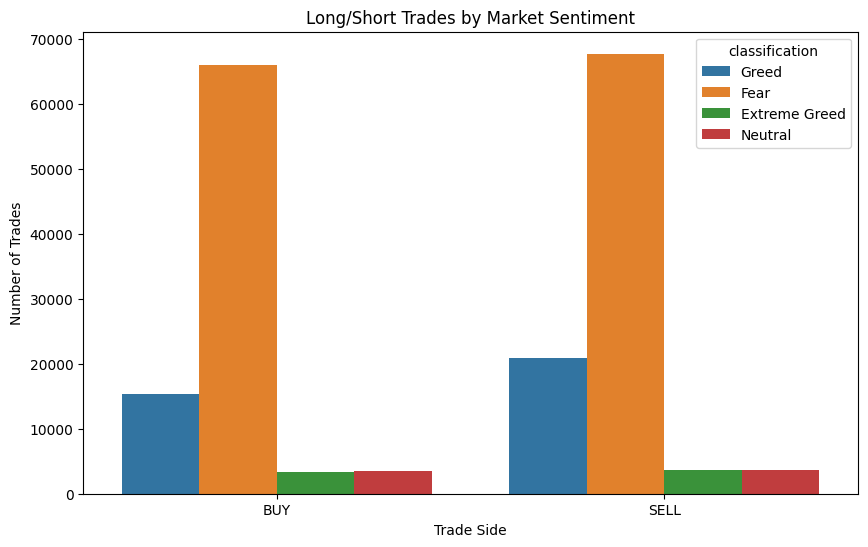

In [47]:

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Side',
    hue='classification'
)

plt.title("Long/Short Trades by Market Sentiment")
plt.xlabel("Trade Side")
plt.ylabel("Number of Trades")

plt.show()

## Correlation Heatmap

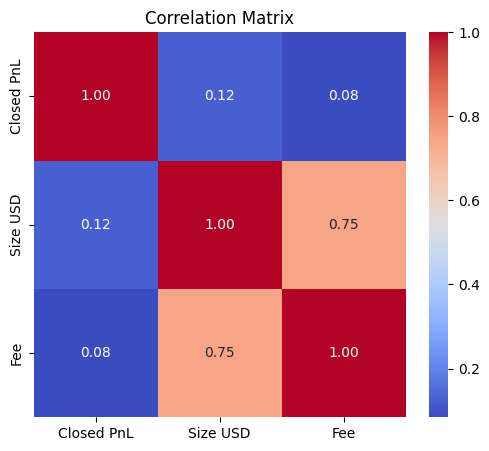

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df[
    [
        'Closed PnL',
        'Size USD',
        'Fee'
    ]
].corr()

# Plot heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

# Trader Segmentation

## Segment 1


### High Leverage

In [51]:

df['Trade_Size_Group'] = np.where(
    df['Size USD'] > df['Size USD'].median(),
    'High',
    'Low'
)

print(df[['Size USD', 'Trade_Size_Group']].head())

   Size USD Trade_Size_Group
0   7872.16             High
1    127.68              Low
2   1150.63             High
3   1142.04             High
4     69.75              Low


## Segment 2

### Frequent Traders

### Trade Count

In [52]:


# Count trades per account
trade_freq = df.groupby('Account').size().reset_index(name='Trades')

# Median number of trades
median_trades = trade_freq['Trades'].median()

# Create Trade Frequency Group
trade_freq['Trade_Frequency'] = np.where(
    trade_freq['Trades'] > median_trades,
    'Frequent',
    'Infrequent'
)

print(trade_freq.head())

                                      Account  Trades Trade_Frequency
0  0x083384f897ee0f19899168e3b1bec365f52a9012    3818        Frequent
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    7280        Frequent
2  0x271b280974205ca63b716753467d5a371de622ab    3809        Frequent
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4   13311        Frequent
4  0x2c229d22b100a7beb69122eed721cee9b24011dd    3239      Infrequent


## Segment 3

### Consistent Winners

In [53]:

# Account-level performance
account_stats = (
    df.groupby('Account')
      .agg(
          Avg_PnL=('Closed PnL', 'mean'),
          Win_Rate=('Win', 'mean')
      )
      .reset_index()
)

# Convert win rate to percentage
account_stats['Win_Rate'] = account_stats['Win_Rate'] * 100

# Create Segment 3
account_stats['Segment_3'] = np.where(
    (account_stats['Avg_PnL'] > 0) &
    (account_stats['Win_Rate'] > 60),
    'Consistent Winners',
    'Normal'
)

print(account_stats.head())

                                      Account     Avg_PnL   Win_Rate Segment_3
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  35.961236    Normal
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654  44.271978    Normal
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043  30.191651    Normal
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530  43.858463    Normal
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011  51.991355    Normal
